# Introduccion

## Objetivo del notebook

En este notebook se transforma el dataset estructurado (tabular) en documentos textuales semánticos aptos para ser utilizados en un sistema RAG (Retrieval-Augmented Generation).

Se define:

- Qué información se expresa como texto narrativo para el LLM

- Qué información se conserva como metadata estructurada

- El formato de los documentos (claridad vs eficiencia)

El objetivo es convertir datos numéricos en “hechos energéticos explicables”, manteniendo coherencia temporal y sectorial.

📌 Analogía argentina:
Acá pasás de una planilla de Excel a un informe técnico legible, que un asesor pueda interpretar.

DESP DEL MVP AGREGAR PRODUCCION PARA PRODUCTO MAS AVANZADO

In [ ]:
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')

ruta_csv = "/content/drive/MyDrive/Energia_Rag/df_rag.csv"
df_analysis = pd.read_csv(ruta_csv, parse_dates=["indice_tiempo"])
df_analysis.dtypes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,0
indice_tiempo,datetime64[ns]
demanda_total,float64
demanda_residencial,float64
comercio_e_industria,float64
grandes_usuarios,float64
temperatura_promedio,float64
potencia_maxima,float64


# BLOQUE 1 — Validaciones analíticas básicas

Objetivo:

Garantizar que las series sean comparables, coherentes y estables antes de interpretar.

Este bloque valida la consistencia temporal y estadística de las series analizadas.
Los valores faltantes observados entre 2001 y 2004 corresponden a ausencia de desagregación sectorial y no a errores de medición, por lo que se consideran NaNs estructurales.


In [ ]:
df_analysis.describe()
df_analysis


,indice_tiempo,demanda_total,demanda_residencial,comercio_e_industria,grandes_usuarios,temperatura_promedio,potencia_maxima
0,2001-01-01,78101.854000,NaN,NaN,NaN,18.485333,14061.000000
1,2002-01-01,76472.890000,NaN,NaN,NaN,18.289667,13481.000000
2,2003-01-01,82213.370000,NaN,NaN,NaN,17.816000,14359.000000
3,2004-01-01,87172.410000,NaN,NaN,NaN,18.442667,15032.000000
4,2005-01-01,92332.950000,30086.495000,43102.875000,19143.580000,18.363667,16143.000000
5,2006-01-01,96812.800000,32608.358000,41291.755000,22912.687000,18.575000,17395.000000
6,2007-01-01,102950.300000,37111.179000,43484.381000,22354.740000,17.650000,18345.000000
7,2008-01-01,105958.100000,38610.044000,43060.486000,24287.570000,19.050000,19126.000000
8,2009-01-01,104622.400000,39564.998000,42648.252000,22409.150000,18.583333,19566.000000
9,2010-01-01,110798.400000,42652.349000,44877.591000,23268.460000,18.066667,20843.000000


Resumen de valores promedio (2001–2024):



| Variable                 | Promedio | Unidad estimada |
|--------------------------|----------|----------------|
| Demanda total            | 115.317  | GWh/año        |
| Demanda residencial      | 50.541   | GWh/año        |
| Comercio e industria     | 47.825   | GWh/año        |
| Grandes usuarios         | 23.817   | GWh/año        |
| Temperatura promedio     | 18.55    | °C             |
| Potencia máxima          | 20.641   | MW             |


# BLOQUE 2 — Evolución temporal (la columna vertebral)

¿Cómo evolucionó la demanda eléctrica argentina en el tiempo y quién explica ese movimiento?


## Evolución de la demanda eléctrica total

La demanda eléctrica total muestra un crecimiento sostenido hasta 2018, seguido por una caída asociada a la crisis macroeconómica y la pandemia. A partir de 2021 se observa una recuperación parcial, aunque sin un retorno claro a la tendencia previa, lo que sugiere un cambio estructural en el patrón de consumo energético.


---------------------------------------------------------------

## Demanda residencial

La demanda residencial presenta un crecimiento persistente a lo largo del período analizado y actúa como amortiguador del sistema durante las crisis económicas. A partir de 2018 se observa un cambio de régimen: el nivel de consumo aumenta, pero no retorna a la pendiente histórica previa, lo que indica una restricción estructural más que una fluctuación transitoria.

---------------------------------------------------------------

## Demanda de comercio e industria

La demanda de comercio e industria se mantiene relativamente estable hasta 2010 y luego muestra un crecimiento moderado hasta mediados de la década de 2010. Posteriormente, se estanca y presenta una leve contracción, reflejando la pérdida de dinamismo de la actividad productiva como motor del consumo eléctrico.

---------------------------------------------------------------

## Demanda de grandes usuarios

Los grandes usuarios impulsan el crecimiento de la demanda eléctrica hasta aproximadamente 2014. A partir de ese año, el consumo se estanca y luego disminuye, sin recuperar la tendencia previa, lo que sugiere una menor utilización de capacidad instalada y un deterioro estructural de la demanda industrial intensiva en energía.



#BLOQUE 3 — Temperatura y estrés del sistema

¿El sistema está creciendo de forma sana o bajo tensión?


## Temperatura promedio

La temperatura promedio anual se mantiene relativamente estable durante todo el período, con variaciones acotadas entre años. Esto indica que los cambios observados en la demanda eléctrica no pueden explicarse principalmente por factores climáticos, sino por transformaciones económicas y estructurales.

---------------------------------------------------------------

##Potencia máxima

La potencia máxima del sistema crece con fuerza hasta 2008 y luego muestra un crecimiento significativamente más lento, a pesar del aumento de la demanda total. Esta divergencia sugiere restricciones en la expansión del sistema eléctrico y un posible estrés estructural en la capacidad para atender picos de consumo.

# BLOQUE 4 — Decisiones explícitas (muy importante)


- Se prioriza el análisis de demanda sobre producción debido a la disponibilidad y consistencia temporal de los datos.
- No se imputan valores faltantes entre 2001 y 2004 para evitar introducir supuestos artificiales en el análisis histórico.
- La demanda residencial se interpreta como variable estabilizadora y no como motor de crecimiento sistémico.
- La potencia máxima se utiliza como proxy de estrés del sistema ante ausencia de indicadores directos de congestión.


A partir de 2014–2015 se observa un quiebre en el comportamiento de los grandes usuarios, que dejan de acompañar el crecimiento de la demanda total. Este cambio de régimen no se revierte en los años posteriores.

No se observa evidencia de que la temperatura promedio anual explique los principales cambios de tendencia en la demanda eléctrica, dado su comportamiento estable a lo largo del período.

La divergencia entre demanda total y potencia máxima sugiere una menor holgura del sistema eléctrico, aumentando la vulnerabilidad ante picos de consumo.


El siguiente gráfico presenta una comparación temporal de distintas variables del sistema eléctrico mediante normalización Min–Max, con el único objetivo de facilitar la comparación visual de sus patrones de evolución.

Esta transformación elimina las unidades físicas originales (MW, GWh, °C) y no implica equivalencia conceptual ni causal entre las variables. En particular, la normalización no corrige diferencias estructurales entre variables endógenas del sistema eléctrico (demanda y potencia) y variables exógenas (temperatura).

Por lo tanto, el gráfico no debe interpretarse como evidencia de causalidad ni como medida de impacto directo entre variables, sino como una herramienta exploratoria para identificar sincronías, quiebres de tendencia y divergencias temporales que orienten análisis posteriores.


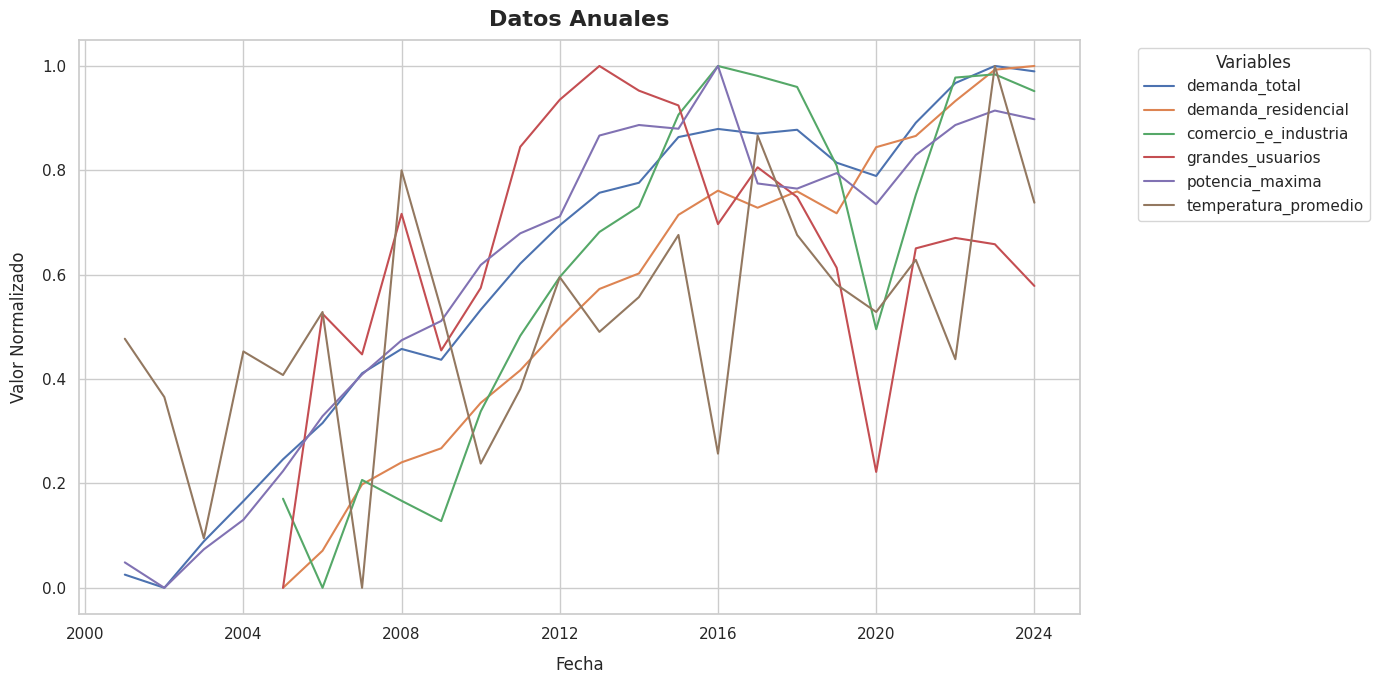

In [ ]:
scaler = MinMaxScaler()
df_norm = df_analysis.copy()

columnas_a_escalar = [
    'demanda_total',
    'demanda_residencial',
    'comercio_e_industria',
    'grandes_usuarios',
    'potencia_maxima',
    'temperatura_promedio'
]

df_norm[columnas_a_escalar] = scaler.fit_transform(
    df_norm[columnas_a_escalar]
)

# 1. Configurar el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 2. Graficar cada columna
for columna in columnas_a_escalar:
    sns.lineplot(data=df_norm, x='indice_tiempo', y=columna, label=columna, linewidth=1.5)

# 3. Personalización estética
plt.title('Datos Anuales', fontsize=16, fontweight='bold', pad=10)
plt.xlabel('Fecha', fontsize=12, labelpad=10)
plt.ylabel('Valor Normalizado', fontsize=12,labelpad=10)
plt.legend(title='Variables', bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera para no tapar
plt.tight_layout()

# 4. Mostrar gráfico
plt.show()